# UPI Fraud Detection — Decision Tree Classifier


In [1]:
import sys
sys.path.append("../src")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay

from models.evaluate import evaluate_model, print_report, print_summary, plot_confusion_matrix

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_SEED = 42

X_train = pd.read_csv("../data/processed/X_train_final.csv")
y_train = pd.read_csv("../data/processed/y_train_final.csv")["is_fraud"]
X_test = pd.read_csv("../data/processed/X_test_final.csv")
y_test = pd.read_csv("../data/processed/y_test_final.csv")["is_fraud"]

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (220930, 61)  Test: (30000, 61)


## 1. Baseline Decision Tree (default hyperparameters)


In [2]:
baseline = DecisionTreeClassifier(random_state=RANDOM_SEED)
baseline.fit(X_train, y_train)

baseline_metrics = evaluate_model(baseline, X_test, y_test, model_name="DecisionTree_baseline", save=False)
print_summary(baseline_metrics)

Model: DecisionTree_baseline
  Accuracy:  0.9893
  Precision: 0.9208
  Recall:    0.9463
  F1 Score:  0.9334
  ROC-AUC:   0.9696


## 2. Hyperparameter Tuning


In [3]:
param_dist = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 8, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}

search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    param_distributions=param_dist, n_iter=20, cv=3,
    scoring="f1", random_state=RANDOM_SEED, n_jobs=-1, verbose=1,
)

t0 = time.time()
search.fit(X_train, y_train)
print(f"\nSearch completed in {time.time() - t0:.1f}s")
print("Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits



Search completed in 106.3s
Best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'entropy'}
Best CV F1: 0.9933


In [4]:
cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
cv_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,params,mean_test_score,std_test_score,rank_test_score
5,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.993331,0.001872,1
16,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.993163,0.001642,2
14,"{'min_samples_split': 5, 'min_samples_leaf': 4...",0.993025,0.001598,3
1,"{'min_samples_split': 2, 'min_samples_leaf': 4...",0.992476,0.001038,4
3,"{'min_samples_split': 20, 'min_samples_leaf': ...",0.992344,0.000674,5
13,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.992095,0.002742,6
2,"{'min_samples_split': 2, 'min_samples_leaf': 8...",0.992017,0.001783,7
10,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.992017,0.001783,7
0,"{'min_samples_split': 5, 'min_samples_leaf': 8...",0.991897,0.001313,9
12,"{'min_samples_split': 10, 'min_samples_leaf': ...",0.991773,0.002788,10


## 3. Final Model Evaluation on Test Set

In [5]:
best_tree = search.best_estimator_
y_pred = best_tree.predict(X_test)

print_report(y_test, y_pred, "Decision Tree (tuned)")

dt_metrics = evaluate_model(best_tree, X_test, y_test, model_name="DecisionTree", save=True)
print_summary(dt_metrics)

=== Decision Tree (tuned) — Classification Report ===
              precision    recall  f1-score   support

    No Fraud       1.00      0.99      1.00     27616
       Fraud       0.93      0.96      0.95      2384

    accuracy                           0.99     30000
   macro avg       0.97      0.98      0.97     30000
weighted avg       0.99      0.99      0.99     30000

Model: DecisionTree
  Accuracy:  0.9914
  Precision: 0.9349
  Recall:    0.9585
  F1 Score:  0.9466
  ROC-AUC:   0.9794


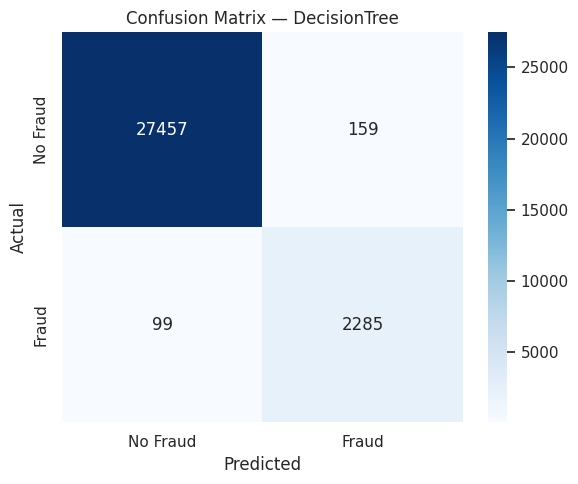

In [6]:
fig, ax = plot_confusion_matrix(dt_metrics, save_path="../reports/figures/16_dt_confusion_matrix.png")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


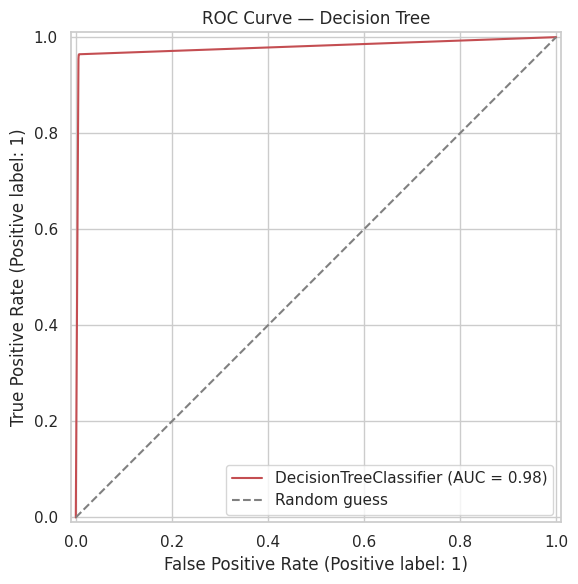

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_estimator(best_tree, X_test, y_test, ax=ax, color="#C44E52")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_title("ROC Curve — Decision Tree")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/17_dt_roc_curve.png", dpi=150)
plt.show()

## 4. Feature Importance
Which engineered features the tree actually relies on for splits.

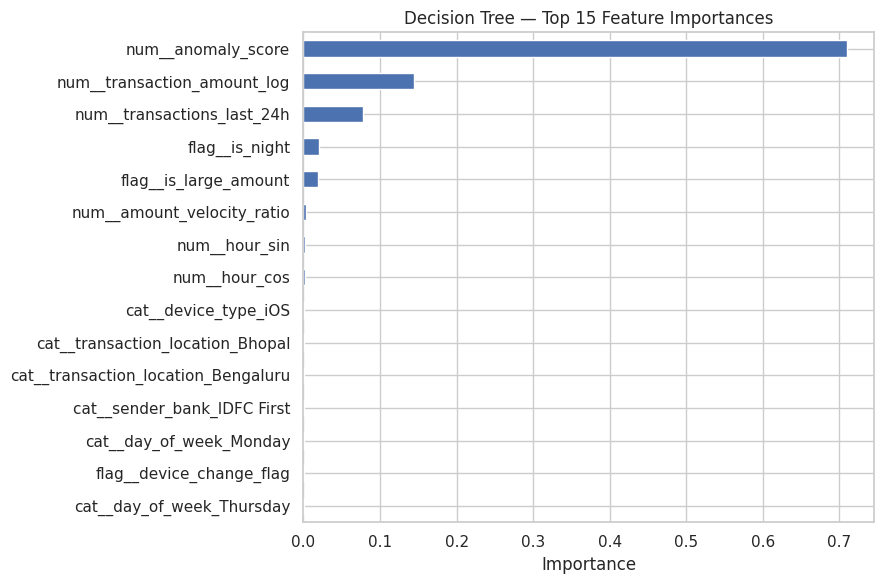

In [8]:
importances = pd.Series(best_tree.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_features.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_title("Decision Tree — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/18_dt_feature_importance.png", dpi=150)
plt.show()

## 5. Visualizing the Tree (top 3 levels)


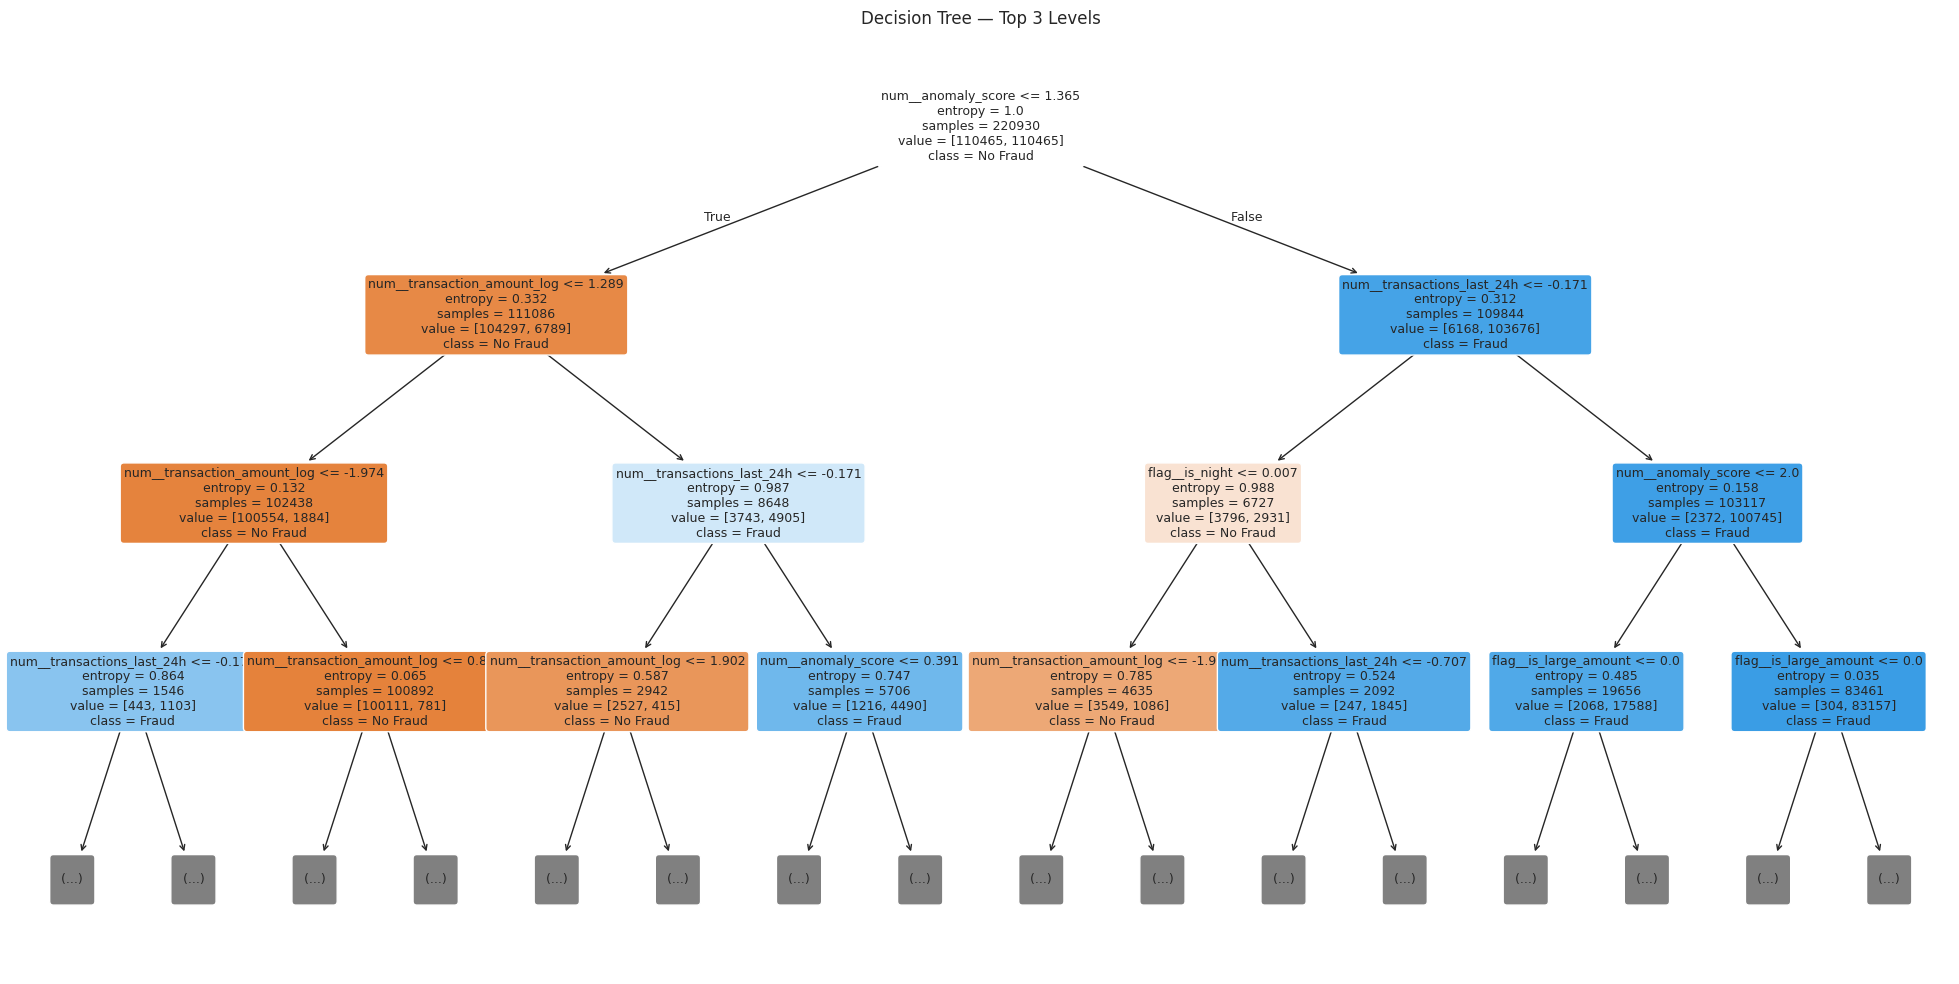

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(best_tree, max_depth=3, feature_names=X_train.columns, class_names=["No Fraud", "Fraud"],
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision Tree — Top 3 Levels")
plt.tight_layout()
plt.savefig("../reports/figures/19_dt_structure.png", dpi=150)
plt.show()

## 6. Save Model

In [10]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_tree, "../models/decision_tree.pkl")
print("Saved to models/decision_tree.pkl")

Saved to models/decision_tree.pkl


## 7. Summary

In [11]:
comparison = pd.DataFrame([
    {"Model": "Baseline (default params)", **{k: baseline_metrics[k] for k in ["accuracy","precision","recall","f1_score"]}},
    {"Model": "Tuned Decision Tree", **{k: dt_metrics[k] for k in ["accuracy","precision","recall","f1_score"]}},
]).set_index("Model").round(4)
comparison

,accuracy,precision,recall,f1_score
Model,,,,
Baseline (default params),0.9893,0.9208,0.9463,0.9334
Tuned Decision Tree,0.9914,0.9349,0.9585,0.9466
